# Exploratory Data Analysis

## Project

LLM-Assisted Explainable Misbehavior Reporting Framework for Cooperative Intelligent Transportation Systems

## Objective

Explore the VeReMi dataset to understand feature distributions, class balance, feature relationships, and prepare for preprocessing and machine learning.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")
sns.set_theme()

DATA_PATH = Path("../data/samples/veremi_sample_100k.csv")

In [3]:
df = pd.read_csv(DATA_PATH)

print(df.shape)

(100000, 21)


In [4]:
df.head()

,Unnamed: 0,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,...,acl_0,acl_1,acl_noise_0,acl_noise_1,hed_0,hed_1,hed_noise_0,hed_noise_1,attack,attack_type
0,0,3,27371.216284,981.098535,908.497891,3.826423,3.964059,-17.723786,-2.154895,-0.024182,...,-0.248402,-0.177659,0.000784,1.114785e-03,-0.971331,-0.237732,44.022409,33.840519,0,RandomSpeedOffset
1,1,3,52060.561117,1213.025174,984.277524,4.477449,4.459375,14.504808,2.605276,-0.008523,...,-0.653850,-0.117125,0.000001,1.847528e-07,0.992578,0.121610,2.560114,8.414909,0,DataReplay
2,2,3,28156.319142,140.514133,944.338854,2.965184,3.066191,-0.346027,4.671520,-0.000469,...,0.333247,-4.486889,0.000448,6.050771e-03,0.256103,0.966649,15.915074,9.636057,1,DoSDisruptive
3,3,3,28671.375689,558.005547,327.316562,4.934159,5.037039,11.792797,4.028876,0.022346,...,-0.030639,-0.010265,0.000066,2.237617e-05,0.954113,0.299446,2.854203,6.203941,1,RandomSpeedOffset
4,4,2,53612.000000,689.179631,547.143780,3.327547,3.374621,3.887137,-8.732709,0.000090,...,-1.829939,4.111129,0.000028,6.361425e-05,0.360402,-0.932797,5.648109,19.951521,0,DoS


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   100000 non-null  int64  
 1   type         100000 non-null  int64  
 2   rcvTime      100000 non-null  float64
 3   pos_0        100000 non-null  float64
 4   pos_1        100000 non-null  float64
 5   pos_noise_0  100000 non-null  float64
 6   pos_noise_1  100000 non-null  float64
 7   spd_0        100000 non-null  float64
 8   spd_1        100000 non-null  float64
 9   spd_noise_0  100000 non-null  float64
 10  spd_noise_1  100000 non-null  float64
 11  acl_0        100000 non-null  float64
 12  acl_1        100000 non-null  float64
 13  acl_noise_0  100000 non-null  float64
 14  acl_noise_1  100000 non-null  float64
 15  hed_0        100000 non-null  float64
 16  hed_1        100000 non-null  float64
 17  hed_noise_0  100000 non-null  float64
 18  hed_noise_1  100000 non-null  float6

In [6]:
df.describe()

,Unnamed: 0,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,spd_noise_1,acl_0,acl_1,acl_noise_0,acl_noise_1,hed_0,hed_1,hed_noise_0,hed_noise_1,attack
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,49999.500000,2.86317,38627.143428,533.907898,661.373431,4.021270,4.021762,1.177759,1.807361,-0.000001,-0.000008,0.042939,0.033311,0.000797,0.000984,-0.069102,0.031846,13.552928,13.305956,0.454710
std,28867.657797,0.34367,12435.467558,411.777816,317.555422,5.299658,5.299129,9.355129,9.788023,0.011593,0.012684,0.942819,1.190766,0.002446,0.002560,0.642759,0.746604,18.386315,18.728038,0.497947
min,0.000000,2.00000,25207.000000,-1859.393275,-1515.626154,0.000000,0.000000,-25.748742,-24.865998,-0.082744,-0.086862,-4.499567,-4.499789,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000
25%,24999.750000,3.00000,27175.056646,195.570038,387.769385,3.488613,3.490026,-2.381601,-3.967096,-0.002377,-0.004024,-0.161666,-0.202027,0.000005,0.000005,-0.669503,-0.773359,3.945700,3.555630,0.000000
50%,49999.500000,3.00000,28610.718864,276.310189,719.316302,3.990100,3.989469,0.000076,0.000337,0.000000,0.000000,0.000075,0.000107,0.000065,0.000066,-0.024397,0.052985,9.346724,8.281785,0.000000
75%,74999.250000,3.00000,51937.419094,902.216151,906.251098,4.490791,4.491642,4.495088,7.764322,0.002448,0.003948,0.220860,0.303303,0.000460,0.000751,0.209544,0.839482,17.443448,17.166257,1.000000
max,99999.000000,3.00000,54184.000000,2681.471465,2368.346332,1438.902073,1438.743799,39.997550,39.979137,0.088609,0.087755,4.500752,4.499895,0.067711,0.070758,1.000000,1.000000,3460.534621,3425.047026,1.000000


In [7]:
df.isnull().sum()

Unnamed: 0     0
type           0
rcvTime        0
pos_0          0
pos_1          0
pos_noise_0    0
pos_noise_1    0
spd_0          0
spd_1          0
spd_noise_0    0
spd_noise_1    0
acl_0          0
acl_1          0
acl_noise_0    0
acl_noise_1    0
hed_0          0
hed_1          0
hed_noise_0    0
hed_noise_1    0
attack         0
attack_type    0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


## 1. Target Variable Distribution

Before training any machine learning model, it is important to examine the distribution of the target variable.

This helps identify whether the dataset is balanced or imbalanced.

The target variable is **attack**, where:

- 0 = Normal Message
- 1 = Malicious Message

In [9]:
attack_counts = df["attack"].value_counts()

attack_counts

attack
0    54529
1    45471
Name: count, dtype: int64

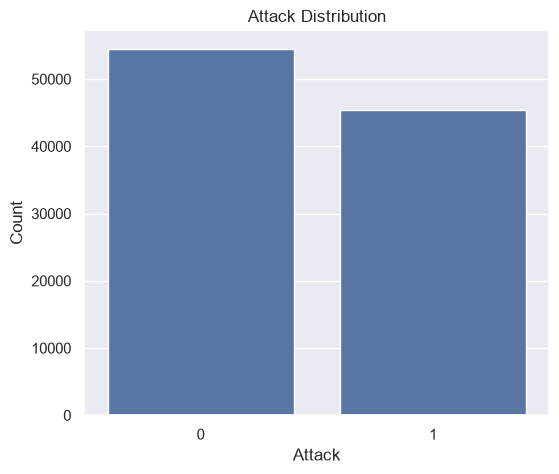

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="attack"
)

plt.title("Attack Distribution")

plt.xlabel("Attack")

plt.ylabel("Count")

plt.show()

In [11]:
attack_percent = (
    df["attack"]
      .value_counts(normalize=True)
      *100
)

attack_percent

attack
0    54.529
1    45.471
Name: proportion, dtype: float64

### Observation

The dataset appears to be reasonably balanced.

This indicates that the classification models are less likely to suffer from severe class imbalance issues.

## 2. Distribution of Attack Types

The dataset contains multiple attack categories.

Understanding their frequency is important because it reveals whether any attack class dominates the dataset.

In [12]:
attack_type_counts = df["attack_type"].value_counts()

attack_type_counts

attack_type
GridSybil             5633
DoS                   5607
DoSRandom             5567
DoSDisruptive         5420
ConstPosOffset        5289
DoSRandomSybil        5288
DataReplaySybil       5273
RandomSpeedOffset     5252
DataReplay            5240
DoSDisruptiveSybil    5227
ConstSpeed            5221
RandomPos             5169
ConstSpeedOffset      5141
Disruptive            5136
RandomPosOffset       5125
ConstPos              5125
RandomSpeed           5108
DelayedMessages       5096
EventualStop          5083
Name: count, dtype: int64

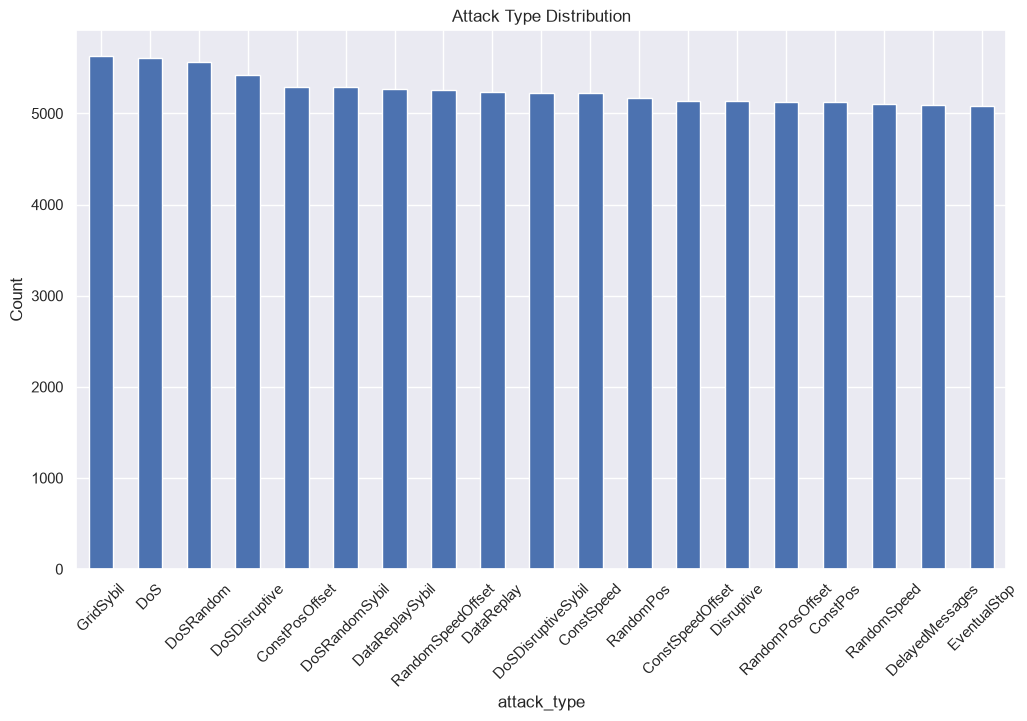

In [13]:
plt.figure(figsize=(12,7))

attack_type_counts.plot(kind="bar")

plt.title("Attack Type Distribution")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

The attack classes appear to be relatively balanced.

This is beneficial because the model will be trained on a diverse collection of attack behaviours.

## 3. Message Type Analysis

The **type** column represents the type of message stored in the dataset.

Understanding its distribution helps determine whether both GPS and BSM messages are present.

In [14]:
df["type"].value_counts()

type
3    86317
2    13683
Name: count, dtype: int64

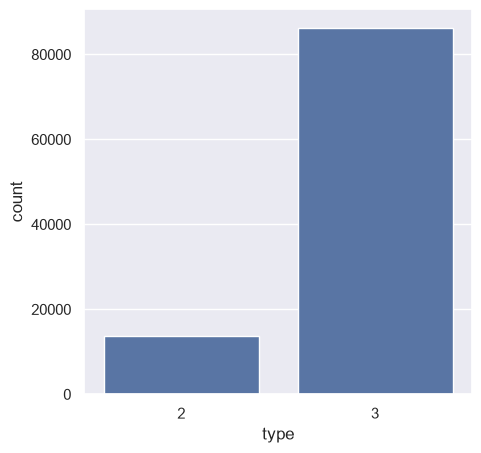

In [15]:
plt.figure(figsize=(5,5))

sns.countplot(
    data=df,
    x="type"
)

plt.show()

### Observation

The dataset contains two message categories:

- Type 2: GPS messages generated by the vehicle itself.
- Type 3: Basic Safety Messages (BSMs) received from neighboring vehicles.

Approximately **86.3%** of the records correspond to BSM messages, while **13.7%** represent GPS messages.

This distribution is expected because vehicles continuously receive safety messages from multiple neighboring vehicles during communication, resulting in a significantly larger number of BSM records.

Since misbehavior detection focuses primarily on identifying manipulated safety messages, the dominance of Type 3 messages aligns well with the project's objective.

## 4. Distribution of Numerical Features

Understanding the distribution of continuous variables helps identify skewness, outliers, and unusual value ranges.

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Unnamed: 0', 'type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0',
       'pos_noise_1', 'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0',
       'acl_1', 'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0',
       'hed_noise_1', 'attack'],
      dtype='str')

In [17]:
numeric_cols = numeric_cols.drop("attack")

In [18]:
numeric_cols = numeric_cols.drop("Unnamed: 0")

In [19]:
numeric_cols

Index(['type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0', 'pos_noise_1',
       'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0', 'acl_1',
       'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0',
       'hed_noise_1'],
      dtype='str')

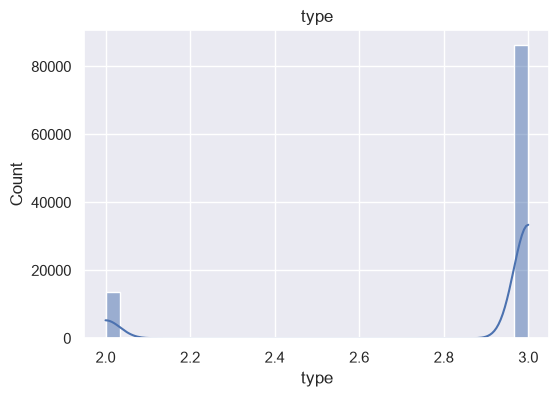

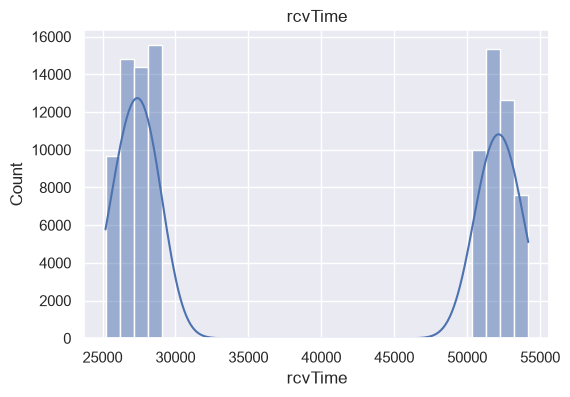

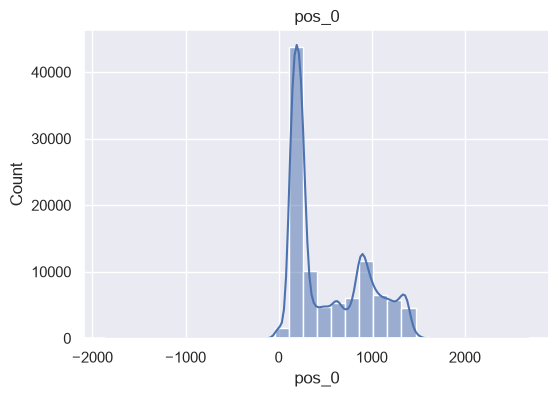

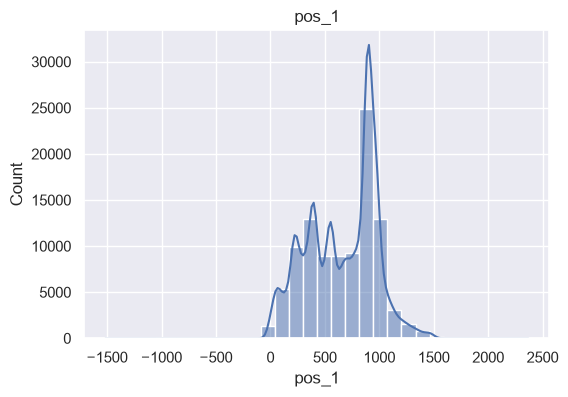

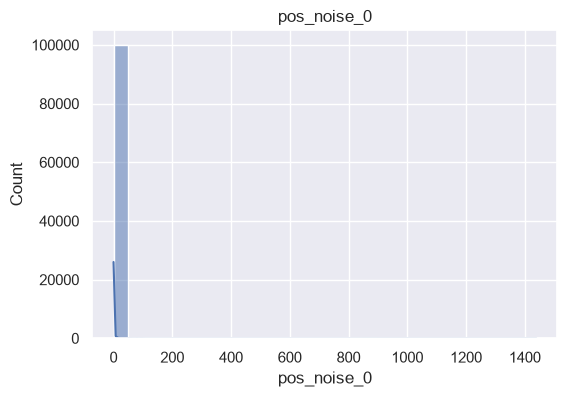

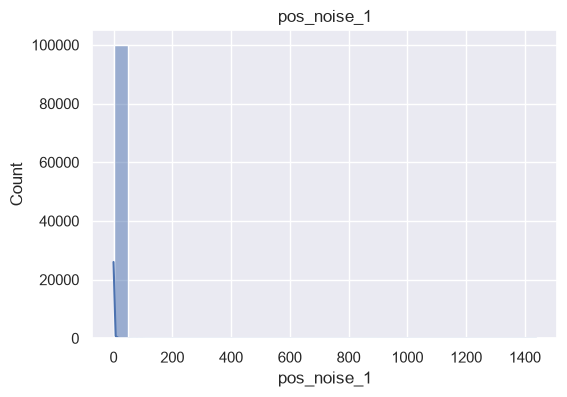

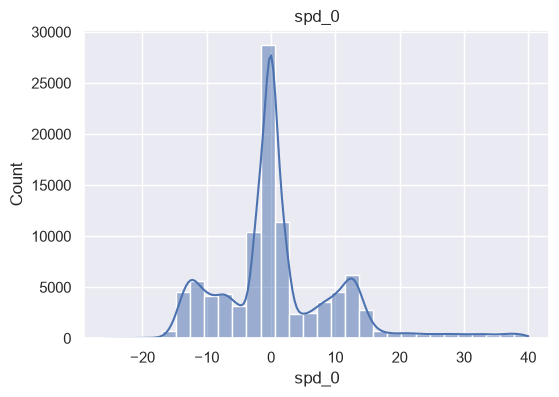

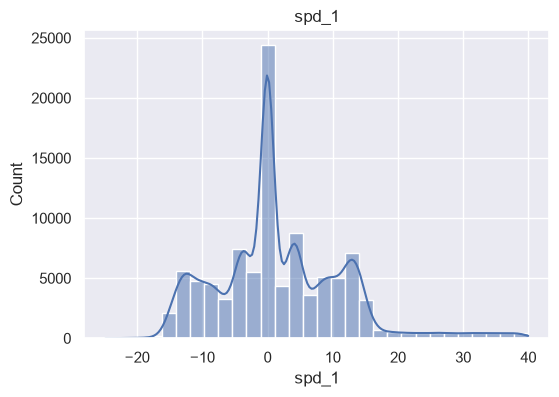

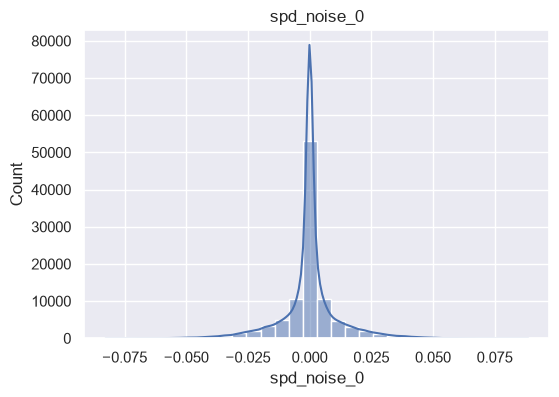

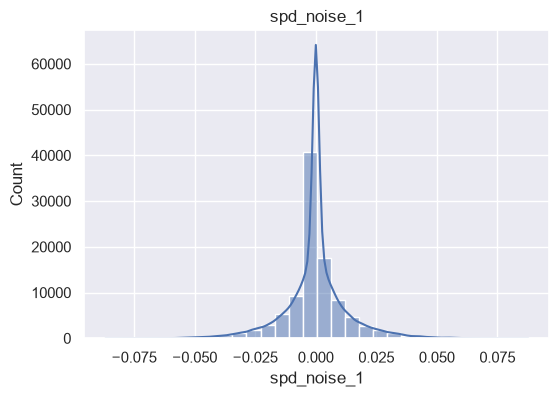

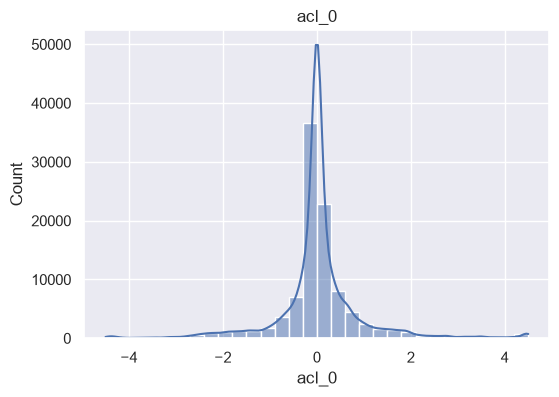

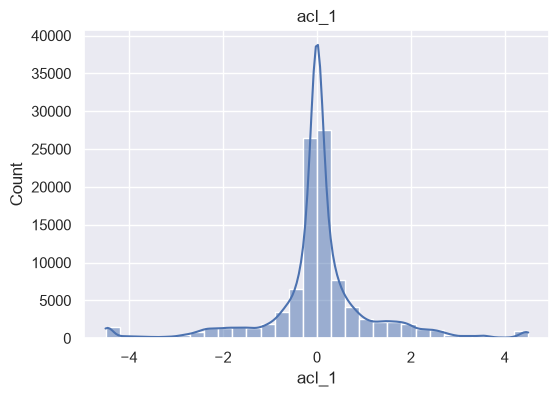

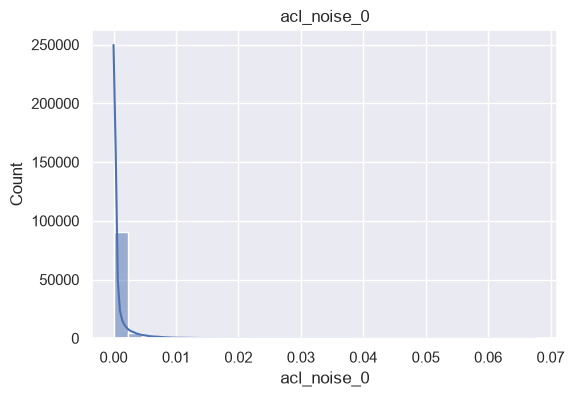

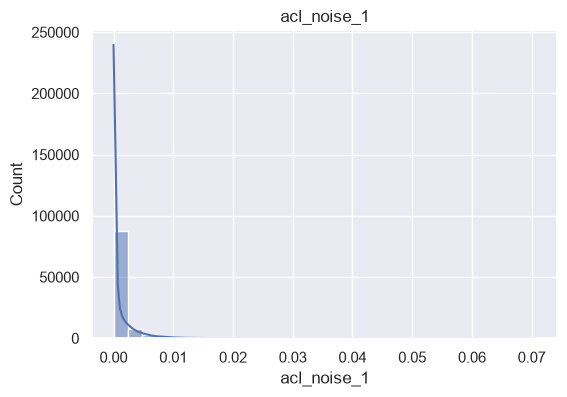

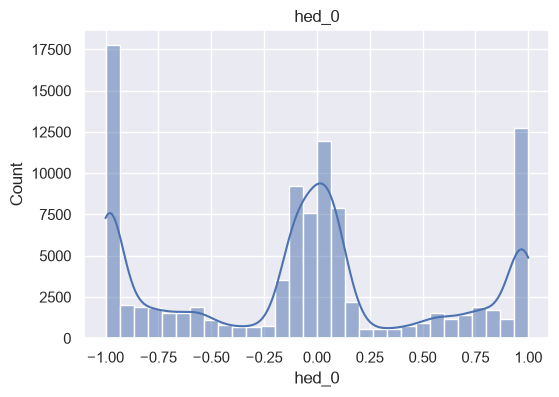

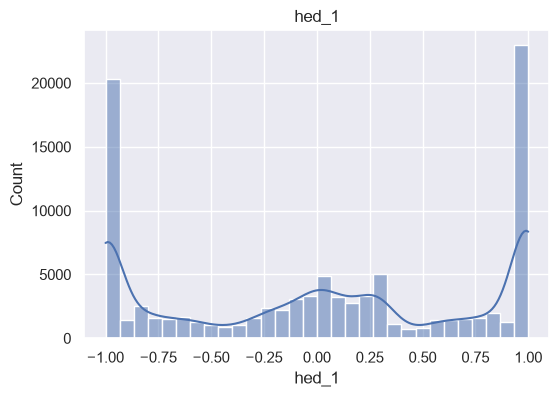

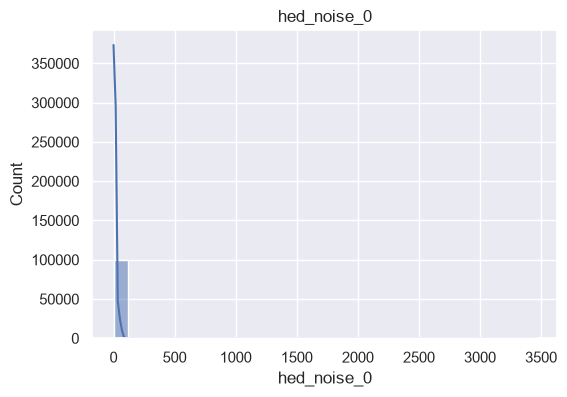

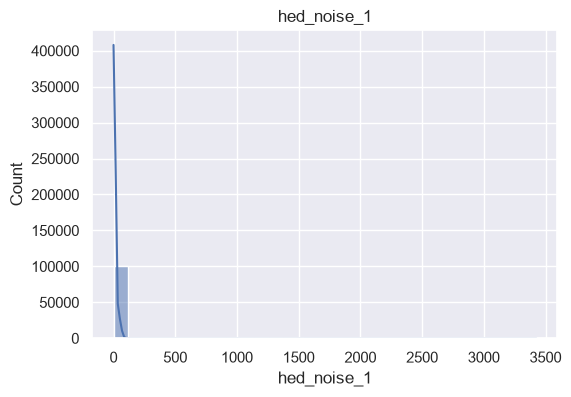

In [20]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )

    plt.title(col)

    plt.show()

## 5. Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and may reveal redundant features.

In [21]:
corr = df.corr(numeric_only=True)

corr

,Unnamed: 0,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,spd_noise_1,acl_0,acl_1,acl_noise_0,acl_noise_1,hed_0,hed_1,hed_noise_0,hed_noise_1,attack
Unnamed: 0,1.000000,-0.006449,0.002669,0.002112,0.000598,-0.004034,-0.004190,-0.000244,-0.002951,0.001179,-0.000798,-0.004775,-0.002207,-0.000969,0.003106,0.001546,0.000384,-0.003452,-0.003512,0.000980
type,-0.006449,1.000000,-0.036888,-0.062126,-0.020116,0.002345,0.002305,0.083690,0.077556,-0.004912,-0.001908,0.017674,0.017730,-0.036960,-0.021650,0.021881,0.004547,-0.020475,-0.004717,0.006475
rcvTime,0.002669,-0.036888,1.000000,-0.084351,0.024882,-0.005684,-0.005746,-0.026015,-0.002783,0.009266,0.006017,0.008404,-0.009922,-0.011314,-0.004212,-0.043379,-0.015355,-0.005176,-0.007856,-0.052055
pos_0,0.002112,-0.062126,-0.084351,1.000000,0.386063,-0.015987,-0.016016,0.040110,-0.020127,-0.004859,0.006662,-0.058251,-0.015756,0.102161,0.051275,-0.030825,-0.077626,0.132090,0.048175,0.019087
pos_1,0.000598,-0.020116,0.024882,0.386063,1.000000,0.007026,0.007025,0.001078,-0.050577,-0.003299,0.000881,-0.005772,-0.124752,0.037777,0.043125,-0.033879,-0.174917,0.052447,0.053696,0.002134
pos_noise_0,-0.004034,0.002345,-0.005684,-0.015987,0.007026,1.000000,0.999308,-0.000968,-0.000215,0.000403,-0.000138,-0.009339,0.003867,0.001299,0.000682,0.005808,-0.001820,0.152657,0.154175,-0.000724
pos_noise_1,-0.004190,0.002305,-0.005746,-0.016016,0.007025,0.999308,1.000000,-0.001211,-0.000471,0.000310,0.000003,-0.009422,0.003991,0.001308,0.000659,0.005409,-0.001869,0.152828,0.154398,-0.000972
spd_0,-0.000244,0.083690,-0.026015,0.040110,0.001078,-0.000968,-0.001211,1.000000,0.409306,-0.004133,-0.005547,0.112797,0.089157,-0.009120,-0.006159,0.635099,0.024552,-0.343543,-0.047167,-0.008389
spd_1,-0.002951,0.077556,-0.002783,-0.020127,-0.050577,-0.000215,-0.000471,0.409306,1.000000,-0.007079,-0.000998,0.104703,0.090168,-0.012905,-0.002055,0.174672,0.600882,-0.067511,-0.377394,-0.010541
spd_noise_0,0.001179,-0.004912,0.009266,-0.004859,-0.003299,0.000403,0.000310,-0.004133,-0.007079,1.000000,0.165699,-0.003407,-0.002524,0.007939,-0.000241,0.005246,0.000942,-0.001749,0.001062,-0.002094


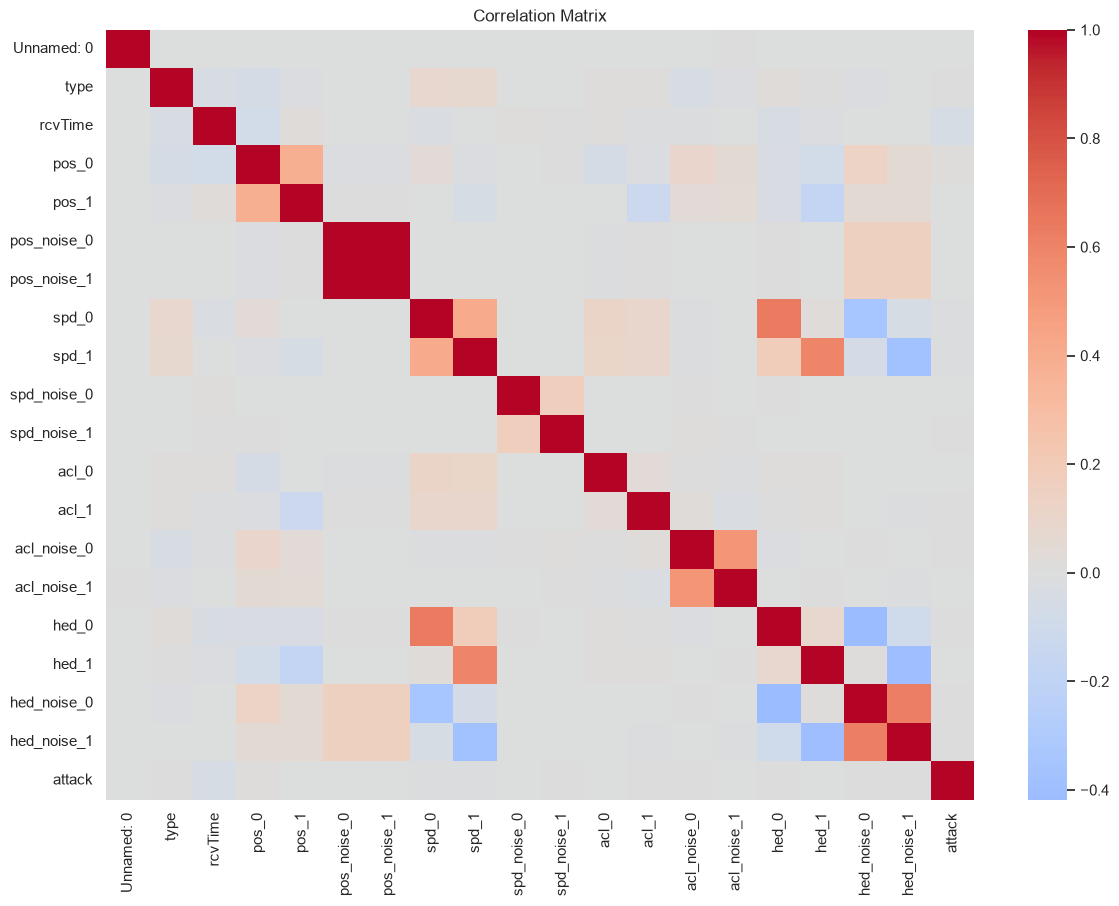

In [22]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Observation

The variables **pos_noise_0** and **pos_noise_1** exhibit an almost perfect positive correlation (≈0.999), indicating that positional noise is applied consistently across both spatial dimensions.

### Observation

A strong positive correlation exists between **spd_0** and **hed_0** (≈0.64), suggesting that vehicle speed and heading components are naturally related through vehicle motion.

### Observation

The target variable **attack** exhibits very weak linear correlations with all numerical features.

This suggests that malicious behavior cannot be identified using any single feature independently. Instead, attack detection likely depends on complex interactions among multiple variables.

This observation supports the use of ensemble machine learning models such as Random Forest and XGBoost, which are capable of learning nonlinear relationships between features.

## Overall Findings

The correlation analysis indicates that:

- Noise-related variables exhibit strong positive correlations because they represent measurements along two spatial dimensions.
- Speed and heading components show moderate to strong relationships, reflecting normal vehicle dynamics.
- No numerical feature demonstrates a strong linear relationship with the target variable (`attack`).

Therefore, effective attack detection will likely require machine learning models capable of capturing nonlinear interactions among multiple features rather than relying on individual variables.

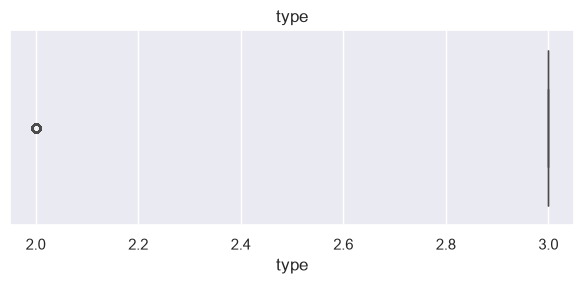

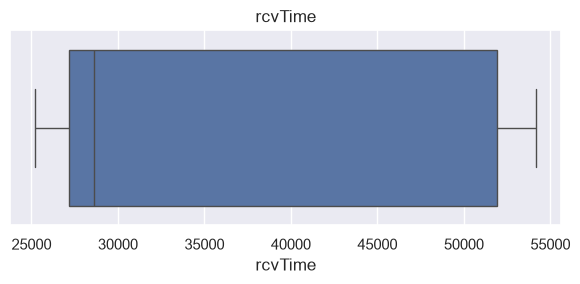

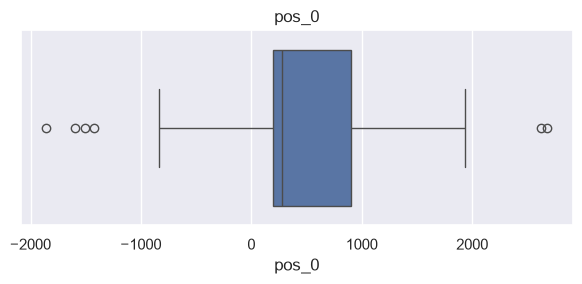

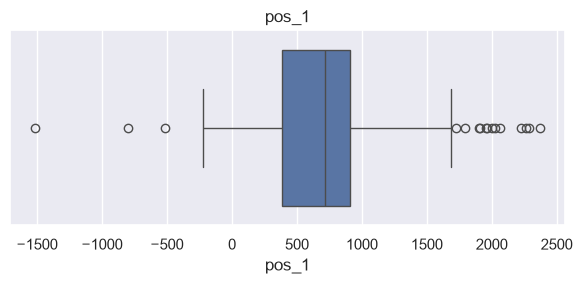

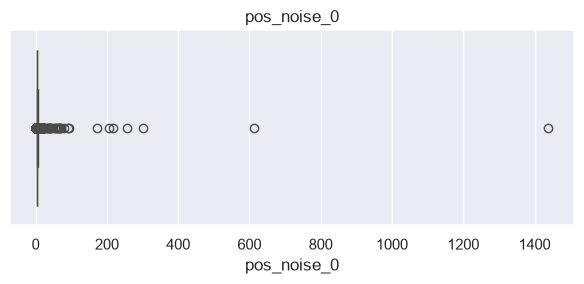

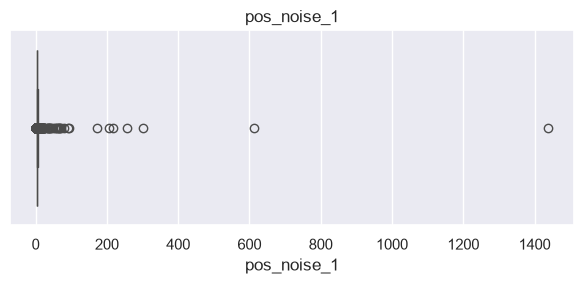

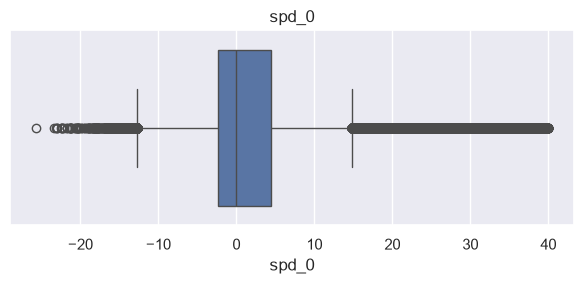

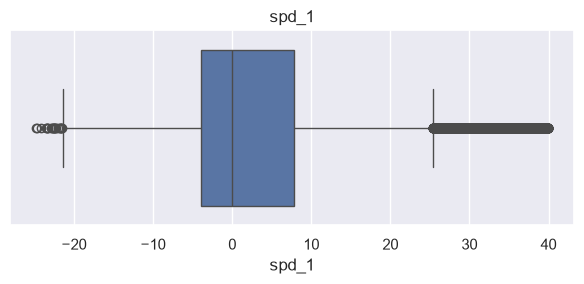

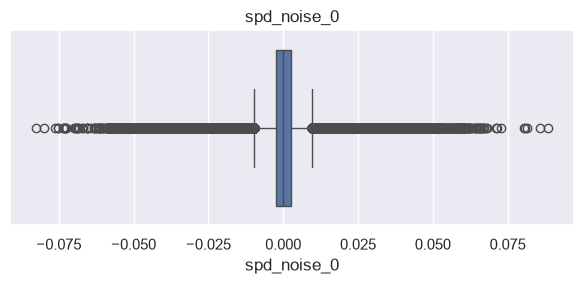

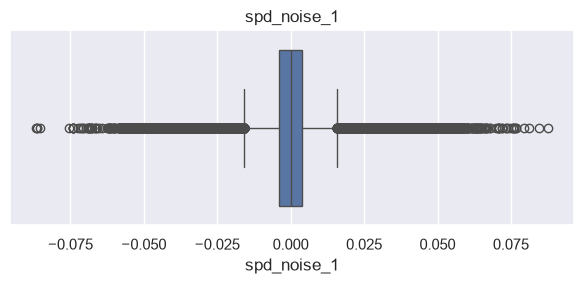

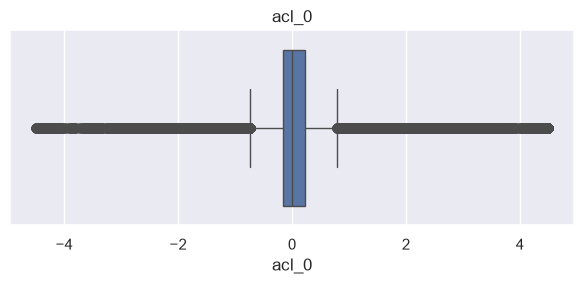

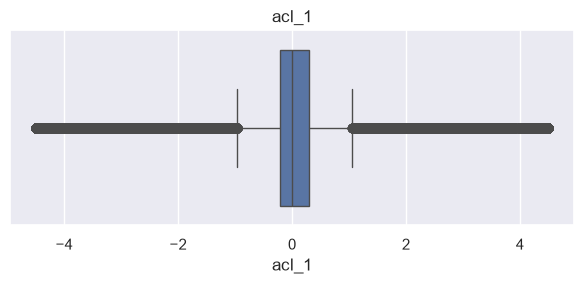

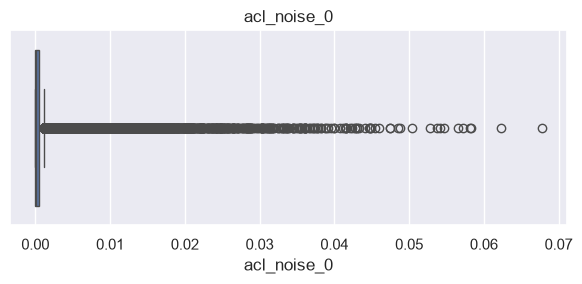

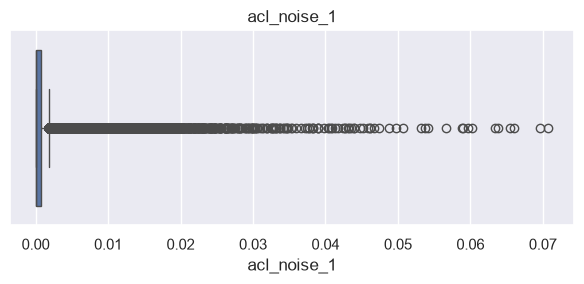

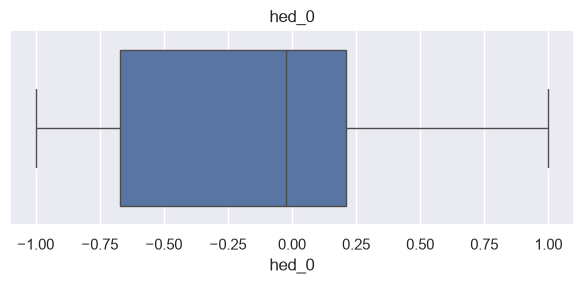

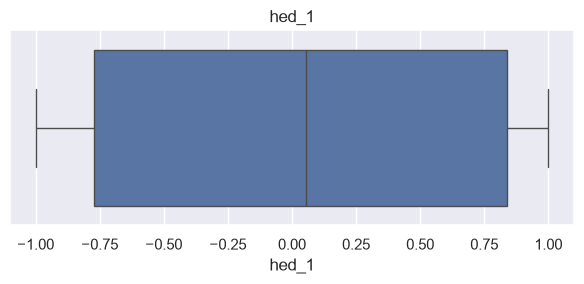

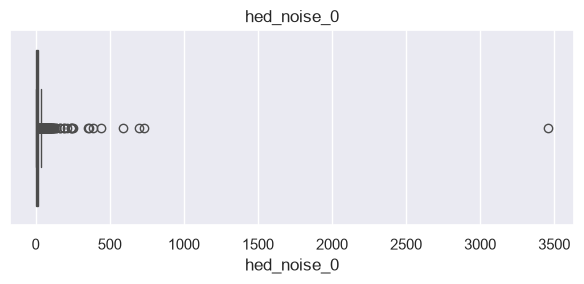

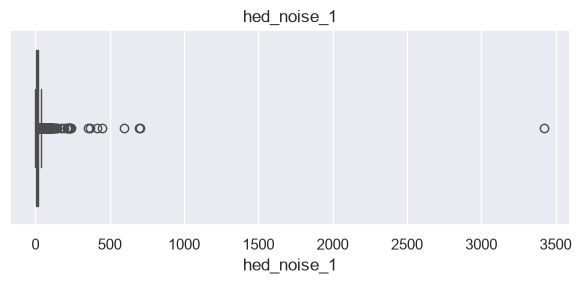

In [23]:
for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.tight_layout()

    plt.savefig(
        f"../outputs/figures/boxplot_{col}.png",
        dpi=300
    )

    plt.show()

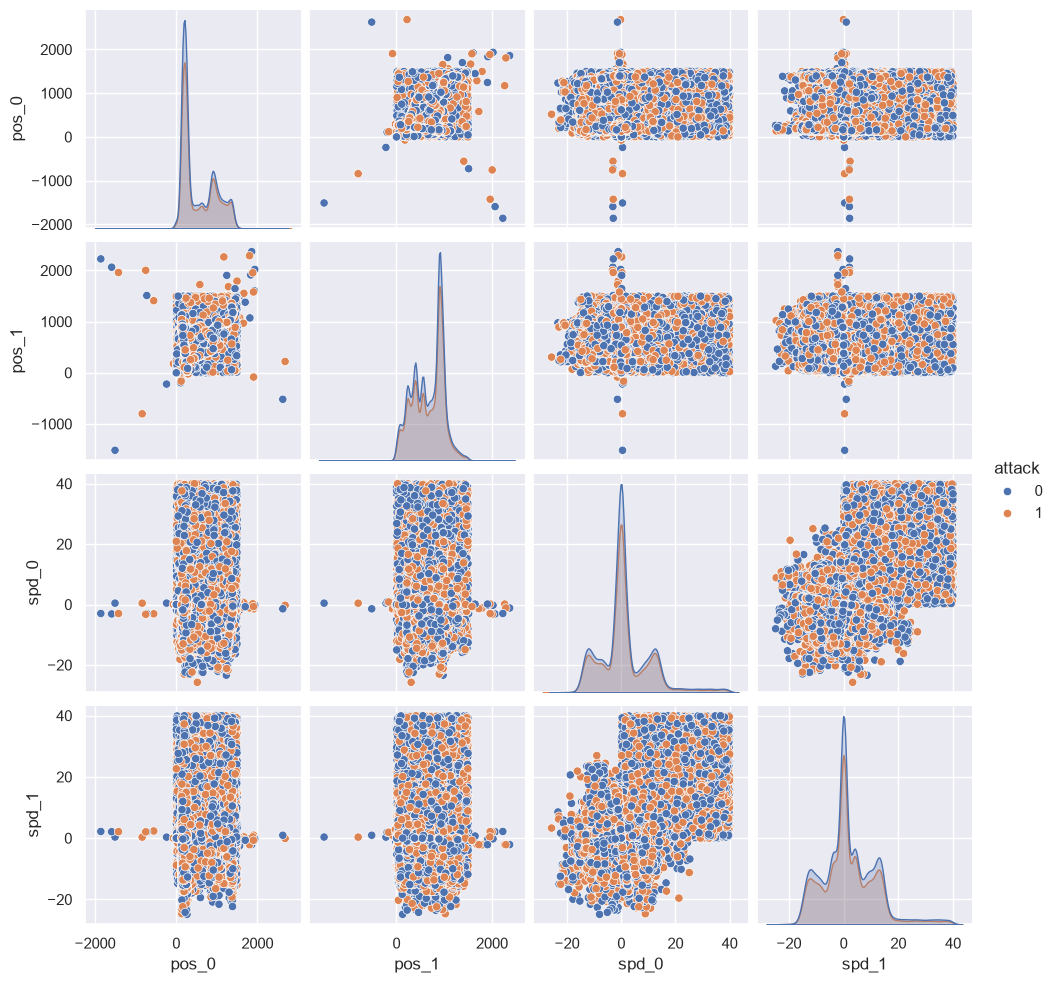

In [24]:
selected = [

"pos_0",
"pos_1",
"spd_0",
"spd_1",
"attack"

]

sns.pairplot(
    df[selected],
    hue="attack"
)

plt.savefig(
"../outputs/figures/pairplot.png",
dpi=300
)

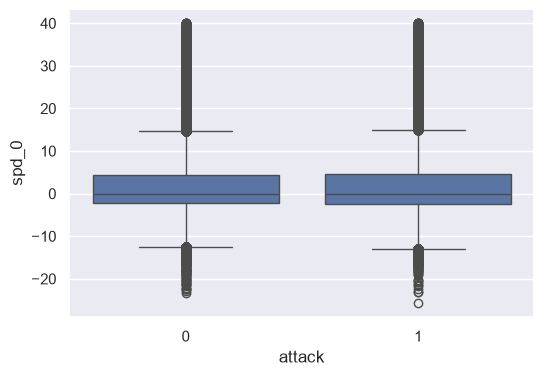

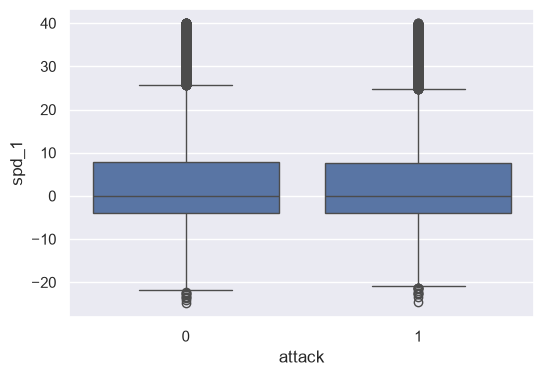

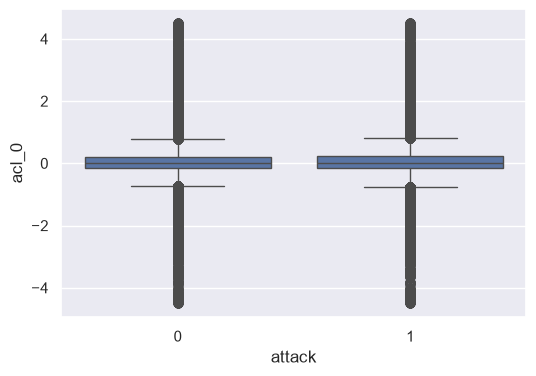

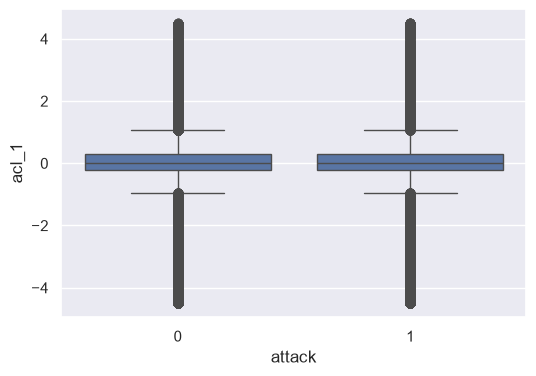

In [25]:
features = [

"spd_0",
"spd_1",
"acl_0",
"acl_1"

]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="attack",
        y=col
    )

    plt.savefig(
        f"../outputs/figures/{col}_vs_attack.png",
        dpi=300
    )

    plt.show()

In [26]:
corr.to_csv(
"../outputs/reports/correlation_matrix.csv"
)